# 07 - Feature Analysis: Weather Variables

## Purpose
This notebook performs comprehensive feature analysis on the **weather/environmental variables** to identify:
1. **Redundant features** - highly correlated pairs (|r| > 0.85)
2. **Multicollinearity** - VIF values indicating collinear variables
3. **Predictive relevance** - correlation with target variable (CRD Mortality Rate)
4. **Feature groupings** - hierarchical clustering patterns

## Goal
Make informed decisions about which weather features to keep/drop before modeling. Drop decisions are carried forward to notebook 08.

## Input
- `data/combined_final/final_combined_all_variables.csv` (from notebook 05)

## Output
- Analysis plots saved to `data/outputs/feature_analysis/`

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

pandas: 2.3.3
numpy: 1.26.4


## 2. Setup Output Directory

In [2]:
output_dir = Path('../data/outputs/feature_analysis')
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

Output directory: ../data/outputs/feature_analysis


## 3. Load Data

In [3]:
df = pd.read_csv('../data/combined_final/final_combined_all_variables.csv')

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Shape: {df.shape}")
print(f"  - Rows: {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]}")
print(f"  - Years: {sorted(df['Year'].unique())}")

DATASET LOADED
Shape: (24487, 131)
  - Rows: 24,487
  - Columns: 131
  - Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


## 4. Define Variables to Exclude

### 4.1 Demographics Variables (analyzed in notebook 06)

In [4]:
demographics_cols = [
    'Median Household Income', 'Total Population', 'Gini Index', 'Median Age',
    'Poverty Rate', 'Unemployment Rate', 'Disability Rate',
    "Bachelor's Degree or Higher (%)", 'High School Degree or Higher (%)',
    'White Population (%)', 'Hispanic Population (%)', 'Black Population (%)',
    'Households with No Vehicle (%)', 'Rent Burden (+50% of HI)', 'Single Mother Families (%)'
]
demographics_cols = [col for col in demographics_cols if col in df.columns]
print(f"Demographics variables to exclude: {len(demographics_cols)}")

Demographics variables to exclude: 15


### 4.2 Livestock Variables

In [5]:
livestock_cols = ['Buffalo', 'Cattle', 'Chicken', 'Duck', 'Goat', 'Horse', 'Pig', 'Sheep']
livestock_cols = [col for col in livestock_cols if col in df.columns]
print(f"Livestock variables to exclude: {len(livestock_cols)}")

Livestock variables to exclude: 8


### 4.3 Pre-defined Irrelevant Weather Variables

These weather variables are known to be redundant or irrelevant and are excluded before analysis.

In [6]:
irrelevant_weather_cols = [
    'PM$_{10}$',
    'FoT PM$_{10}$ above EPA threshold',
    'FoT PM$_{10}$ above75\u1d57\u02b0 percentile',
    'FoT PM$_{1}$ above75\u1d57\u02b0 percentile',
    'PM$_1$',
    'Specific humidity.1',
    'Total column water',
    '2m dew point temperature',
    '2m temperature',
    'PM$_{2.5}$',
    'FoT Temperature above 90 $\\mathrm{^o F}$',
    'FoT Temperature below 0 $\\mathrm{^o C}$',
    'FoT PM$_{2.5}$ above EPA threshold',
    'Temperature',
    'Surface geopotential',
    'Dust aerosol (0.03-0.55 \u00b5m) mixing ratio',
    'Nitrogen dioxide',
    'Peroxyacetyl nitrate',
    'Formaldehyde',
    'Sulphur dioxide',
    'Nitric acid',
    'Propane',
    'Nitrogen monoxide',
    'Ozone',
    'Hydrogen peroxide',
    'Specific humidity',
    'Total AOD at 469 nm',
    'Total AOD at 550 nm',
    'Total AOD at 670 nm',
    'Total AOD at 865 nm',
    'Total AOD at 1240 nm',
    'Total column carbon monoxide',
    'Total column ethane',
    'Total column formaldehyde',
    'Total column hydrogen peroxide',
    'Total column hydroxyl radical',
    'Total column isoprene',
    'Total column methane',
    'Total column nitric acid',
    'Total column nitrogen dioxide',
    'Total column ozone',
    'Total column peroxyacetyl nitrate',
    'Total column propane',
    'Total column sulphur dioxide',
    'Total column water vapour',
    'Total column nitrogen monoxide',
    'Vertically integrated mass of dust aerosol (0.03-0.55 \u00b5m)',
    'Vertically integrated mass of dust aerosol (0.55-9 \u00b5m)',
    'Vertically integrated mass of dust aerosol (9-20 \u00b5m)',
    'Vertically integrated mass of hydrophilic black carbon aerosol',
    'Vertically integrated mass of hydrophilic organic matter aerosol',
    'Vertically integrated mass of hydrophobic organic matter aerosol',
    'Vertically integrated mass of hydrophobic black carbon aerosol',
    'Vertically integrated mass of sea salt aerosol (0.03-0.5 \u00b5m)',
    'Vertically integrated mass of sea salt aerosol (0.5-5 \u00b5m)',
    'Vertically integrated mass of sea salt aerosol (5-20 \u00b5m)',
    'Vertically integrated mass of sulphate aerosol',
    'Vertically integrated mass of sulphur dioxide'
]

irrelevant_weather_cols = [col for col in irrelevant_weather_cols if col in df.columns]
print(f"Irrelevant weather variables to exclude: {len(irrelevant_weather_cols)}")

Irrelevant weather variables to exclude: 58


### 4.4 Identifiers and Target Variable

In [7]:
identifiers = ['County', 'State', 'Year', 'fips']
target = ['CRD Mortality Rate']

identifiers = [col for col in identifiers if col in df.columns]
target = [col for col in target if col in df.columns]

print(f"Identifiers to exclude: {len(identifiers)}")
print(f"Target variable: {target}")

Identifiers to exclude: 4
Target variable: ['CRD Mortality Rate']


## 5. Extract Weather Variables

In [8]:
print("=" * 70)
print("EXTRACTING WEATHER VARIABLES")
print("=" * 70)

exclude_cols = identifiers + target + demographics_cols + livestock_cols + irrelevant_weather_cols

weather_cols = [col for col in df.columns if col not in exclude_cols]
weather_df = df[weather_cols + ['CRD Mortality Rate']].copy()

print(f"\nTotal columns to exclude: {len(exclude_cols)}")
print(f"  - Identifiers: {len(identifiers)}")
print(f"  - Target: {len(target)}")
print(f"  - Demographics: {len(demographics_cols)}")
print(f"  - Livestock: {len(livestock_cols)}")
print(f"  - Irrelevant weather: {len(irrelevant_weather_cols)}")
print(f"\nWeather variables remaining for analysis: {len(weather_cols)}")

EXTRACTING WEATHER VARIABLES

Total columns to exclude: 86
  - Identifiers: 4
  - Target: 1
  - Demographics: 15
  - Livestock: 8
  - Irrelevant weather: 58

Weather variables remaining for analysis: 45


## 6. List Weather Variables

In [9]:
print("=" * 70)
print(f"WEATHER VARIABLES TO ANALYZE ({len(weather_cols)})")
print("=" * 70)
for i, col in enumerate(sorted(weather_cols), 1):
    print(f"  {i:2}. {col}")

WEATHER VARIABLES TO ANALYZE (45)
   1. 10m wind speed
   2. Black carbon AOD at 550 nm
   3. Carbon monoxide
   4. Dust AOD at 550 nm
   5. Dust aerosol (0.55-0.9 µm) mixing ratio
   6. Dust aerosol (0.9-20 µm) mixing ratio
   7. Ethane
   8. FoT Carbonmonoxide above75ᵗʰ percentile
   9. FoT Ethane above75ᵗʰ percentile
  10. FoT Formaldehyde above75ᵗʰ percentile
  11. FoT Hydrogen peroxide above75ᵗʰ percentile
  12. FoT Hydroxyl radical above75ᵗʰ percentile
  13. FoT Isoprene above75ᵗʰ percentile
  14. FoT Nitric acid above75ᵗʰ percentile
  15. FoT Nitrogen dioxide above75ᵗʰ percentile
  16. FoT Nitrogen monoxide above75ᵗʰ percentile
  17. FoT Ozone above75ᵗʰ percentile
  18. FoT PM$_{2.5}$ above75ᵗʰ percentile
  19. FoT Peroxyacetyl Nitrate above75ᵗʰ percentile
  20. FoT Propane above75ᵗʰ percentile
  21. FoT Sulphur dioxide above75ᵗʰ percentile
  22. FoT Temperature above75ᵗʰ percentile
  23. FoT Temperature below25ᵗʰ percentile
  24. Hydrophilic black carbon aerosol mixing ratio
  

## 7. Descriptive Statistics

In [10]:
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

missing = weather_df.isnull().sum()
if missing.sum() > 0:
    print("\nMissing values detected:")
    for col in missing[missing > 0].index:
        print(f"  {col}: {missing[col]:,}")
else:
    print("\nNo missing values")

print("\nSummary statistics:")
weather_df[weather_cols].describe()

DESCRIPTIVE STATISTICS

No missing values

Summary statistics:


,Black carbon AOD at 550 nm,Dust AOD at 550 nm,Land-sea mask,Mean sea level pressure,Organic matter AOD at 550 nm,Sea salt AOD at 550 nm,Sulphate AOD at 550 nm,Surface pressure,Carbon monoxide,Dust aerosol (0.55-0.9 µm) mixing ratio,...,FoT Nitric acid above75ᵗʰ percentile,FoT Nitrogen dioxide above75ᵗʰ percentile,FoT Nitrogen monoxide above75ᵗʰ percentile,FoT Ozone above75ᵗʰ percentile,FoT Hydrogen peroxide above75ᵗʰ percentile,FoT PM$_{2.5}$ above75ᵗʰ percentile,FoT Propane above75ᵗʰ percentile,FoT Sulphur dioxide above75ᵗʰ percentile,FoT Temperature above75ᵗʰ percentile,FoT Temperature below25ᵗʰ percentile
count,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,2.448700e+04,2.448700e+04,...,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000,24487.000000
mean,0.006957,0.006823,0.940175,101717.215378,0.074638,0.007459,0.050543,96732.896935,1.630836e-07,7.073325e-10,...,31.300438,27.023090,15.376378,43.344840,25.527466,34.349782,26.494420,23.346542,43.663401,36.309714
std,0.001643,0.004220,0.117245,112.263376,0.013602,0.004336,0.015252,5275.659436,2.044880e-08,5.765845e-10,...,9.485320,14.714983,9.153050,6.302588,9.318040,10.506852,19.200888,23.766495,15.496757,15.786625
min,0.002853,0.000965,0.134455,101190.734156,0.025448,0.002506,0.016799,71376.504085,9.749192e-08,3.756149e-11,...,3.415301,0.223881,0.717213,19.774590,0.239071,3.219178,0.000000,0.000000,1.980874,0.000000
25%,0.005912,0.003684,0.962231,101640.656337,0.067629,0.004796,0.037099,96184.613921,1.517833e-07,2.999832e-10,...,26.232877,15.479452,8.915922,39.452055,18.458904,27.306548,11.815068,0.922131,32.864163,24.212329
50%,0.006670,0.005818,0.984592,101728.993033,0.075164,0.005836,0.053757,98358.289992,1.636864e-07,5.409942e-10,...,31.061644,25.785519,13.732877,43.731343,24.417808,36.369863,22.438525,15.932836,42.739726,37.739726
75%,0.007674,0.008871,0.993097,101800.802399,0.083752,0.008669,0.062913,99859.437344,1.730789e-07,9.519616e-10,...,36.678082,37.910448,19.535519,47.157534,31.830601,42.020548,40.684932,40.582192,53.512611,48.664384
max,0.020297,0.030306,0.999933,102016.076978,0.119383,0.046040,0.107583,101854.756871,6.502018e-07,8.035914e-09,...,92.979452,86.407104,76.061644,88.424658,79.212329,76.161202,98.664384,96.815068,99.280822,79.781421


## 8. Inter-Feature Correlation Analysis

### 8.1 Correlation Matrix Heatmap (Without Annotations)

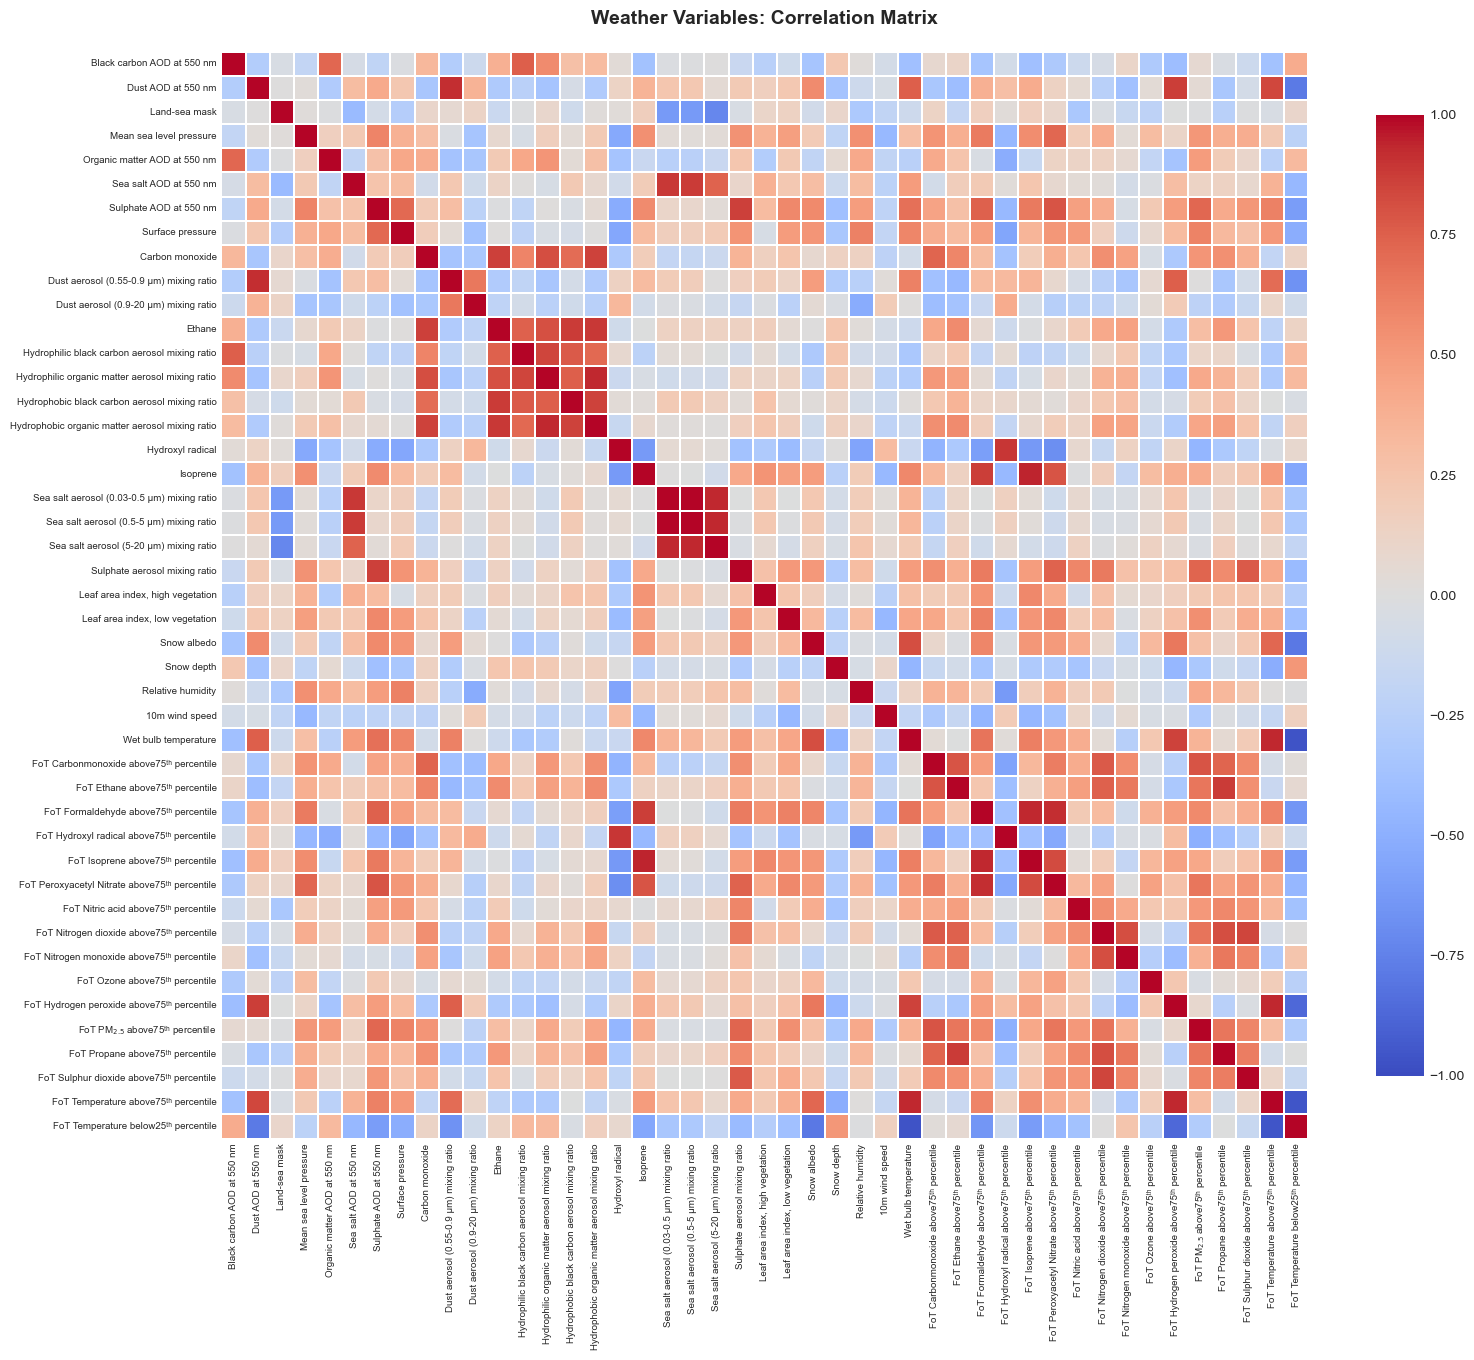

Saved: weather_correlation_heatmap.png


In [11]:
corr_matrix = weather_df[weather_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.3,
            cbar_kws={'shrink': 0.8},
            ax=ax)
ax.set_title('Weather Variables: Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(output_dir / 'weather_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: weather_correlation_heatmap.png")

### 8.2 High Correlation Pairs (|r| > 0.85)

In [12]:
print("=" * 70)
print("HIGH CORRELATION PAIRS (|r| > 0.85)")
print("=" * 70)

threshold = 0.85
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Variable 1': corr_matrix.columns[i],
                'Variable 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(f"\nFound {len(high_corr_pairs)} high-correlation pairs:")
    print(high_corr_df.to_string(index=False))
else:
    print("\nNo pairs with |r| > 0.85 found")

HIGH CORRELATION PAIRS (|r| > 0.85)

Found 26 high-correlation pairs:
                                     Variable 1                                      Variable 2  Correlation
    Sea salt aerosol (0.03-0.5 µm) mixing ratio        Sea salt aerosol (0.5-5 µm) mixing ratio        1.000
                           Wet bulb temperature            FoT Temperature below25ᵗʰ percentile       -0.967
           FoT Temperature above75ᵗʰ percentile            FoT Temperature below25ᵗʰ percentile       -0.954
                                       Isoprene               FoT Isoprene above75ᵗʰ percentile        0.943
       Sea salt aerosol (0.5-5 µm) mixing ratio         Sea salt aerosol (5-20 µm) mixing ratio        0.937
          FoT Formaldehyde above75ᵗʰ percentile               FoT Isoprene above75ᵗʰ percentile        0.935
                           Wet bulb temperature            FoT Temperature above75ᵗʰ percentile        0.933
    Sea salt aerosol (0.03-0.5 µm) mixing ratio         Se

### 8.3 Hierarchical Clustering Dendrogram

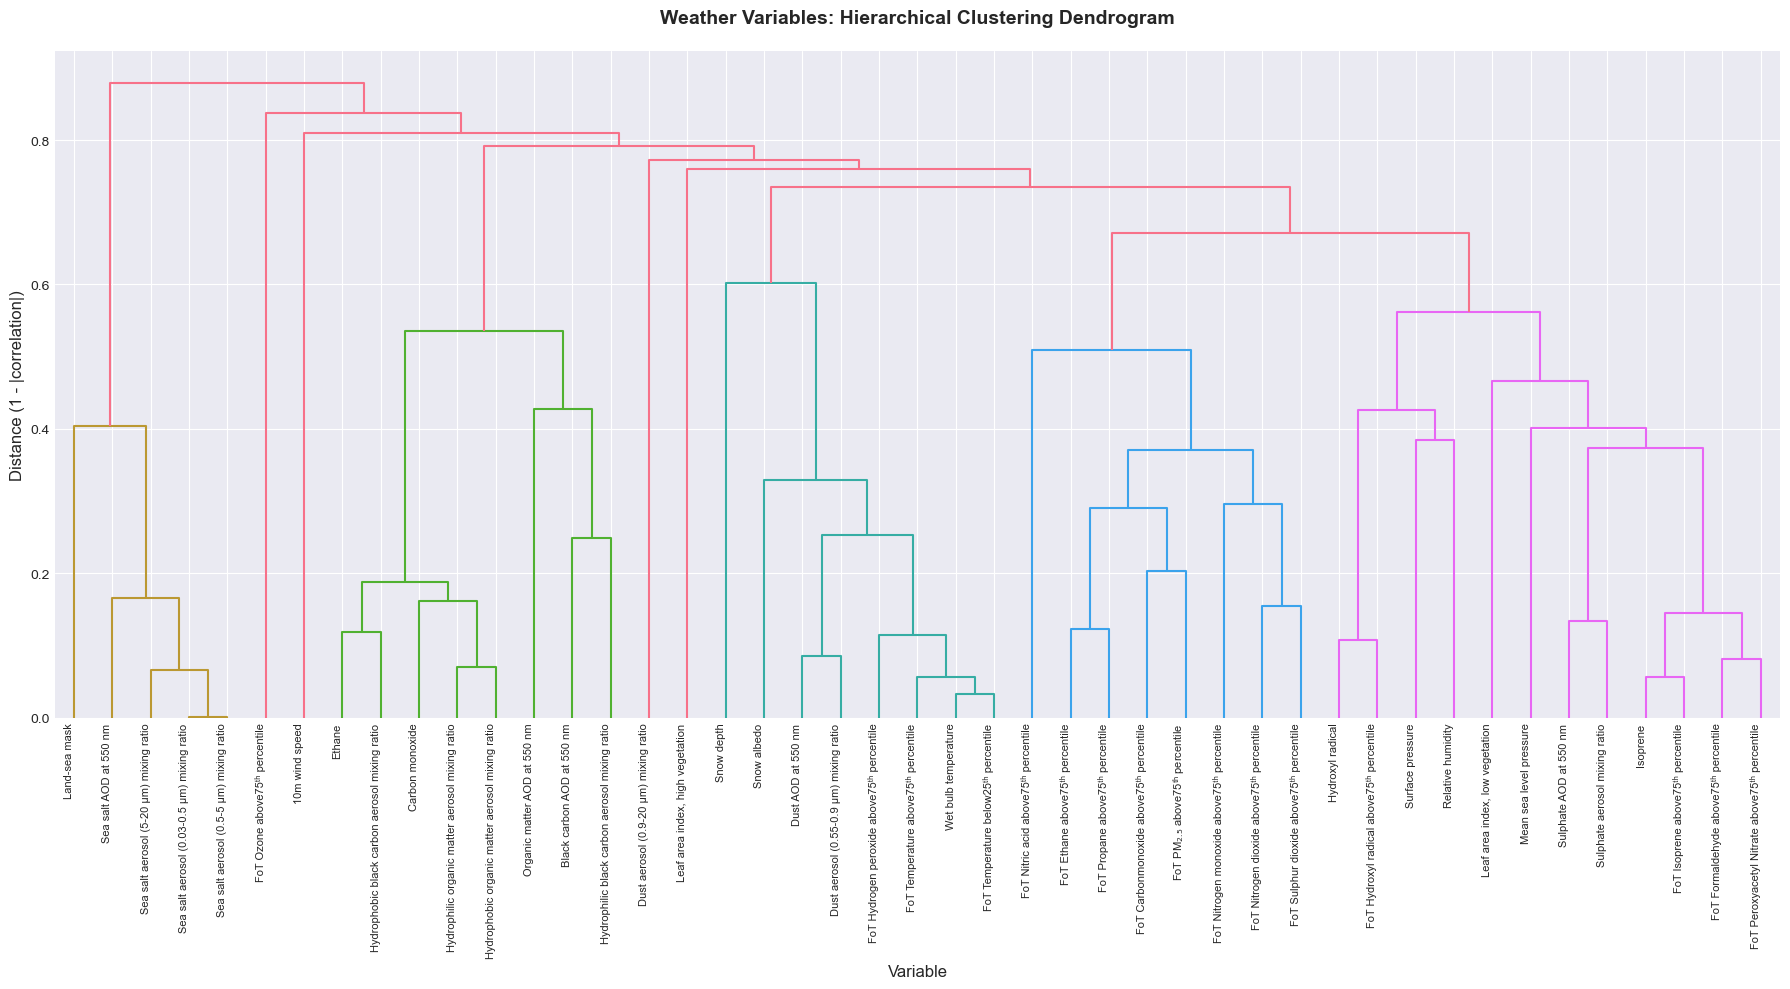

Saved: weather_dendrogram.png


In [13]:
distance_matrix = 1 - np.abs(corr_matrix)
linkage_matrix = linkage(squareform(distance_matrix), method='average')

fig, ax = plt.subplots(figsize=(18, 10))
dendrogram(linkage_matrix,
           labels=corr_matrix.columns,
           orientation='top',
           distance_sort='ascending',
           show_leaf_counts=False,
           leaf_font_size=8,
           ax=ax)
ax.set_title('Weather Variables: Hierarchical Clustering Dendrogram',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Variable', fontsize=12)
ax.set_ylabel('Distance (1 - |correlation|)', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.savefig(output_dir / 'weather_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: weather_dendrogram.png")

## 9. Relationship with Target Variable

### 9.1 Feature-Target Correlation

FEATURE CORRELATION WITH TARGET (CRD Mortality Rate)

Ranked by absolute correlation:

FoT Formaldehyde above75ᵗʰ percentile              0.468
FoT Peroxyacetyl Nitrate above75ᵗʰ percentile      0.427
FoT Isoprene above75ᵗʰ percentile                  0.417
Isoprene                                           0.413
Snow albedo                                        0.329
Wet bulb temperature                               0.325
Sulphate AOD at 550 nm                             0.305
FoT Temperature below25ᵗʰ percentile              -0.302
Mean sea level pressure                            0.297
FoT Temperature above75ᵗʰ percentile               0.292
FoT Hydrogen peroxide above75ᵗʰ percentile         0.284
Sulphate aerosol mixing ratio                      0.262
FoT Ozone above75ᵗʰ percentile                     0.258
Land-sea mask                                      0.247
Black carbon AOD at 550 nm                        -0.244
Dust AOD at 550 nm                                 0.239
F

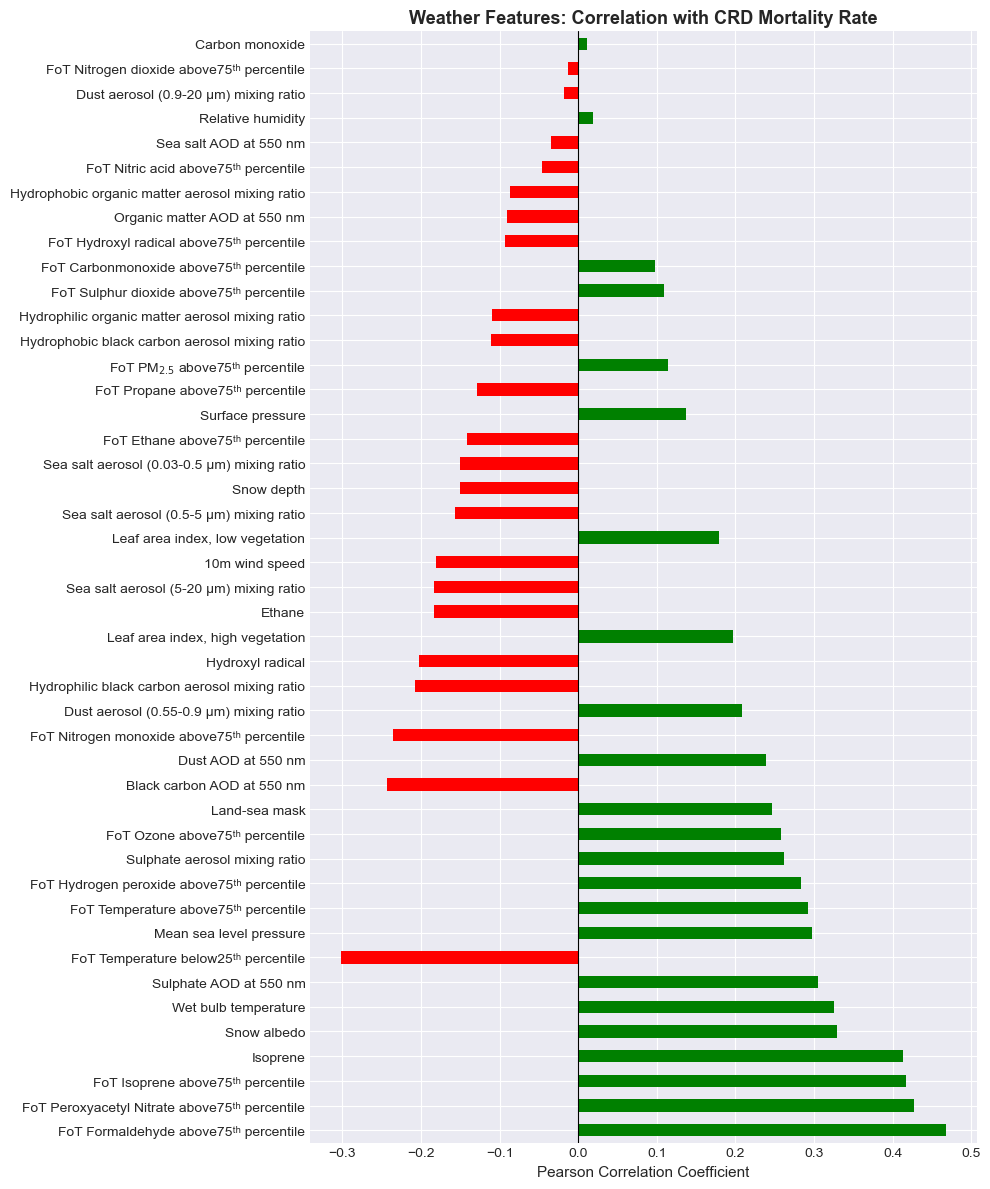

Saved: weather_target_correlation.png


In [14]:
target_corr = weather_df[weather_cols].corrwith(weather_df['CRD Mortality Rate'])
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("=" * 70)
print("FEATURE CORRELATION WITH TARGET (CRD Mortality Rate)")
print("=" * 70)
print("\nRanked by absolute correlation:")
print("\n" + target_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Weather Features: Correlation with CRD Mortality Rate',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=11)
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(output_dir / 'weather_target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: weather_target_correlation.png")

### 9.2 Bivariate Scatter Plots (Top 9 Features)

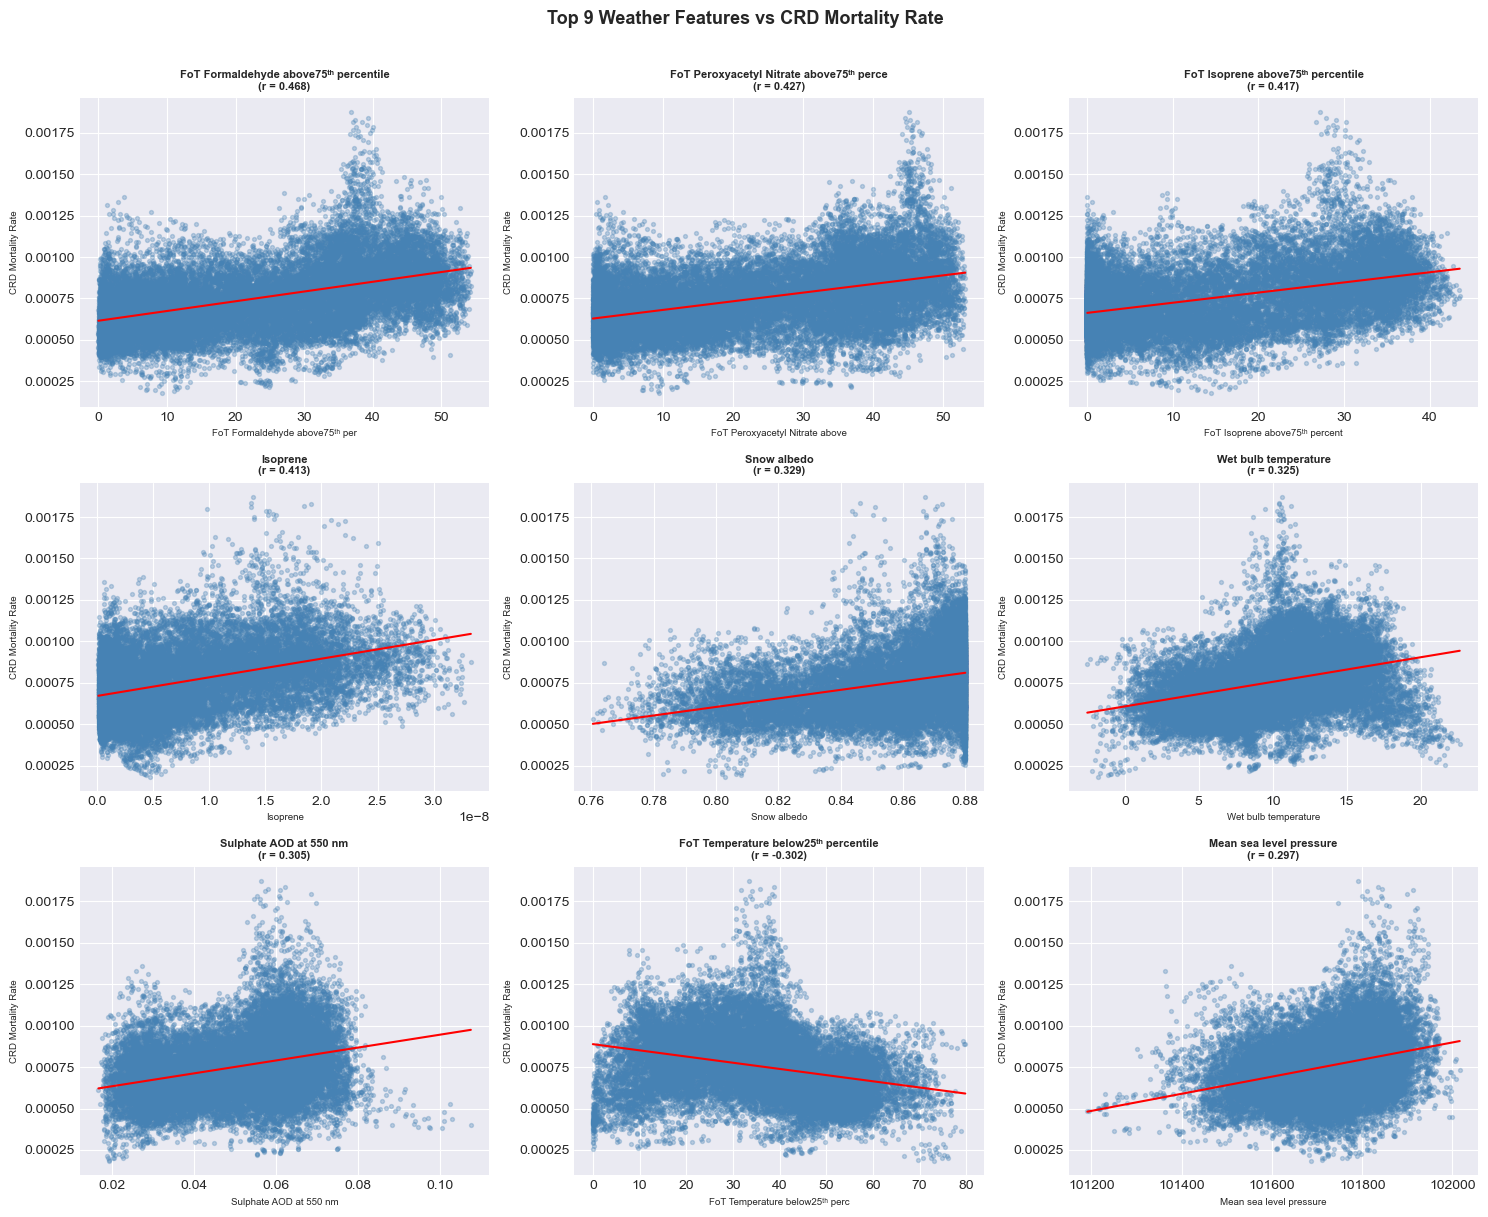

Saved: weather_scatter_top9.png


In [15]:
top_features = target_corr.abs().nlargest(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    ax.scatter(weather_df[feature],
               weather_df['CRD Mortality Rate'],
               alpha=0.3, s=8, color='steelblue')
    z = np.polyfit(weather_df[feature].dropna(),
                   weather_df.loc[weather_df[feature].notna(), 'CRD Mortality Rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(weather_df[feature].min(), weather_df[feature].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=1.5)
    r = target_corr[feature]
    ax.set_title(f'{feature[:40]}\n(r = {r:.3f})', fontsize=8, fontweight='bold')
    ax.set_xlabel(feature[:30], fontsize=7)
    ax.set_ylabel('CRD Mortality Rate', fontsize=7)

plt.suptitle('Top 9 Weather Features vs CRD Mortality Rate', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(output_dir / 'weather_scatter_top9.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: weather_scatter_top9.png")

## 10. Drop Decision: Redundant Weather Variables

Based on the correlation analysis above, the following weather variables are identified as redundant (highly correlated with other retained variables, or weak predictive signal). These are carried forward to notebook 08.

In [16]:
redundant_weather = [
    'Dust aerosol (0.9-20 \u00b5m) mixing ratio',
    'Hydrophobic black carbon aerosol mixing ratio',
    'Sea salt aerosol (5-20 \u00b5m) mixing ratio',
    'Dust aerosol (0.55-0.9 \u00b5m) mixing ratio',
    'Sea salt aerosol (0.5-5 \u00b5m) mixing ratio',
    'Hydrophilic black carbon aerosol mixing ratio',
    'Sulphate aerosol mixing ratio',
    'Hydroxyl radical',
    'FoT Temperature below25\u1d57\u02b0 percentile',
    'FoT Temperature above75\u1d57\u02b0 percentile',
    'Sea salt aerosol (0.03-0.5 \u00b5m) mixing ratio',
    'Hydrophobic organic matter aerosol mixing ratio',
    'Carbon monoxide',
    'Ethane',
    'Hydrophilic organic matter aerosol mixing ratio',
    'Isoprene',
    'Snow albedo',
    'Surface pressure',
    'FoT Peroxyacetyl Nitrate above75\u1d57\u02b0 percentile',
    'FoT Isoprene above75\u1d57\u02b0 percentile',
    'FoT Hydrogen peroxide above75\u1d57\u02b0 percentile',
    'Relative humidity',
    'Buffalo'
]

redundant_weather_found = [col for col in redundant_weather if col in df.columns]

print("=" * 70)
print("REDUNDANT WEATHER VARIABLES TO DROP")
print("=" * 70)
print(f"\nTotal: {len(redundant_weather_found)}")
for i, col in enumerate(redundant_weather_found, 1):
    r = target_corr.get(col, float('nan'))
    r_str = f'r={r:.3f}' if not pd.isna(r) else 'not in weather analysis'
    print(f"  {i:2}. {col}  ({r_str})")

REDUNDANT WEATHER VARIABLES TO DROP

Total: 23
   1. Dust aerosol (0.9-20 µm) mixing ratio  (r=-0.018)
   2. Hydrophobic black carbon aerosol mixing ratio  (r=-0.111)
   3. Sea salt aerosol (5-20 µm) mixing ratio  (r=-0.183)
   4. Dust aerosol (0.55-0.9 µm) mixing ratio  (r=0.209)
   5. Sea salt aerosol (0.5-5 µm) mixing ratio  (r=-0.156)
   6. Hydrophilic black carbon aerosol mixing ratio  (r=-0.207)
   7. Sulphate aerosol mixing ratio  (r=0.262)
   8. Hydroxyl radical  (r=-0.202)
   9. FoT Temperature below25ᵗʰ percentile  (r=-0.302)
  10. FoT Temperature above75ᵗʰ percentile  (r=0.292)
  11. Sea salt aerosol (0.03-0.5 µm) mixing ratio  (r=-0.150)
  12. Hydrophobic organic matter aerosol mixing ratio  (r=-0.086)
  13. Carbon monoxide  (r=0.011)
  14. Ethane  (r=-0.184)
  15. Hydrophilic organic matter aerosol mixing ratio  (r=-0.110)
  16. Isoprene  (r=0.413)
  17. Snow albedo  (r=0.329)
  18. Surface pressure  (r=0.137)
  19. FoT Peroxyacetyl Nitrate above75ᵗʰ percentile  (r=0.427)
